In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sudalairajkumar/indian-startup-funding/startup_funding.csv
/kaggle/input/datasets/rudrapatwa233/startup-cleanded-data-or-preprocessed/startup_cleaned.csv


In [9]:
df=pd.read_csv('/kaggle/input/datasets/sudalairajkumar/indian-startup-funding/startup_funding.csv')

In [10]:
df['Startup Name'].unique().tolist()

['BYJU’S',
 'Shuttl',
 'Mamaearth',
 'https://www.wealthbucket.in/',
 'Fashor',
 'Pando',
 'Zomato',
 'Ecozen',
 'CarDekho',
 'Dhruva Space',
 'Rivigo',
 'Healthians',
 'Licious',
 'InCred',
 'Trell',
 'Rein Games',
 'Lenskart.com',
 'Freshworks',
 'Misters',
 'Sunstone Eduversity Pvt. Ltd',
 'Burger Singh',
 'Ninjacart',
 'Aye Finance',
 'SuperGaming',
 'Clumio',
 'eBikeGo',
 'Digital Mall Asia',
 'Medikabazaar',
 'Vogo Automotive',
 'Furtados School of Music',
 'Paytm',
 'Dunzo',
 'Udaan',
 'The Man Company',
 'FPL Technologies',
 'Cashflo',
 'Digital F5',
 '3rdFlix',
 '75F',
 'Myelin Foundry',
 'Atomberg Technology',
 'GOQii',
 'Vyapar App',
 'Progcap',
 'MyPetrolPump',
 'Alteria Capital',
 'Pine Labs',
 'Meesho',
 'Cars24',
 'Uniphore',
 'Zendrive',
 'Lo! Foods',
 'Tala',
 'INDwealth',
 'HungerBox',
 'AdmitKard',
 'Mishry Reviews',
 'Grofers',
 'Rapido Bike Taxi',
 'RenewBuy',
 'Atlan',
 'WizCounsel',
 'Ola Cabs',
 'Daalchini Technologies',
 '"BYJU\\\\\'S"',
 'Moglix',
 'Ezyhaul',


In [11]:
df['Investors']=df['Investors Name'].fillna('Undisclosed')

In [12]:
df['Investors Name'].tolist()

['Tiger Global Management',
 'Susquehanna Growth Equity',
 'Sequoia Capital India',
 'Vinod Khatumal',
 'Sprout Venture Partners',
 'Chiratae Ventures',
 'Ant Financial',
 'Sathguru Catalyzer Advisors',
 'Ping An Global Voyager Fund',
 'Mumbai Angels, Ravikanth Reddy',
 'SAIF Partners, Spring Canter Investment Ltd.',
 'Paytm, NPTK, Sabre Partners and Neoplux',
 'Vertex Growth Fund',
 nan,
 'Ruizheng Investment',
 'Manipal Education and Medical Group (MEMG)',
 'SoftBank Vision Fund',
 'Sequoia, CapitalG, Accel',
 'Sauce.vc, Rainforest Ventures',
 'Prime Venture Partners, LetsVenture, PS1 Venture and GlobalLogic co-founder Rajul Garg',
 'RB Investments',
 'DG Daiwa Ventures, DG Incubation',
 'Trifecta Capital Advisors',
 'FinTech',
 'Dream Incubator',
 'Altimeter Capital, Sutter Hill Ventures',
 'Startup Buddy',
 'Amour Infrastructure',
 'Ackermans & van Haaren, HealthQuad, Rebright Partners, Toppan Printing',
 'Matrix Partners, Stellaris Venture Partners, Kalaari Capital',
 'IAN Fund an

In [13]:
df.head()

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks,Investors
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN,Tiger Global Management
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN,Susquehanna Growth Equity
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN,Sequoia Capital India
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN,Vinod Khatumal
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN,Sprout Venture Partners


Preprocessing 
* drop remarks col
* set index sno
* rename col
* convert amount to Cr rs
* date col
* dropna

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3044 entries, 0 to 3043
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Sr No              3044 non-null   int64 
 1   Date dd/mm/yyyy    3044 non-null   object
 2   Startup Name       3044 non-null   object
 3   Industry Vertical  2873 non-null   object
 4   SubVertical        2108 non-null   object
 5   City  Location     2864 non-null   object
 6   Investors Name     3020 non-null   object
 7   InvestmentnType    3040 non-null   object
 8   Amount in USD      2084 non-null   object
 9   Remarks            419 non-null    object
 10  Investors          3044 non-null   object
dtypes: int64(1), object(10)
memory usage: 261.7+ KB


In [15]:
# removed because Remarks colums has no data almost 90 % data missing
df.drop(columns=['Remarks'],inplace=True)

In [16]:
df.set_index('Sr No',inplace=True)

In [17]:
df.rename(columns={
    'Date dd/mm/yyyy':'date',
    'Startup Name':'startup',
    'Industry Vertical':'vertical',
    'SubVertical':'subvertical',
    'City  Location':'city',
    'Investors Name':'investors',
    'InvestmentnType':'round',
    'Amount in USD':'amount'
},inplace=True)

In [18]:
# convert amount to CR rs
df['amount']=df['amount'].fillna('0')

In [19]:
df['amount']=df['amount'].str.replace(',','')

In [20]:
df['amount']=df['amount'].str.replace('undisclosed','0')
df['amount']=df['amount'].str.replace('unknown','0')
df['amount']=df['amount'].str.replace('Undisclosed','0') 

In [21]:
df=df[df['amount'].str.isdigit()]

In [22]:
df['amount']=df['amount'].astype(int)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3029 entries, 1 to 3044
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         3029 non-null   object
 1   startup      3029 non-null   object
 2   vertical     2858 non-null   object
 3   subvertical  2104 non-null   object
 4   city         2849 non-null   object
 5   investors    3005 non-null   object
 6   round        3027 non-null   object
 7   amount       3029 non-null   int64 
 8   Investors    3029 non-null   object
dtypes: int64(1), object(8)
memory usage: 236.6+ KB


In [24]:
def to_inr(dollar):
    inr=dollar * 82.5
    return inr / 10000000

In [25]:
df['amount']=df['amount'].apply(to_inr)

In [26]:
df['amount']

Sr No
1       1650.000000
2         66.399250
3        151.460595
4         24.750000
5         14.850000
           ...     
3040      37.125000
3041       6.806250
3042      12.375000
3043       0.000000
3044       1.155000
Name: amount, Length: 3029, dtype: float64

In [27]:
df.head()

,date,startup,vertical,subvertical,city,investors,round,amount,Investors
Sr No,,,,,,,,,
1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1650.000000,Tiger Global Management
2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,66.399250,Susquehanna Growth Equity
3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,151.460595,Sequoia Capital India
4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,24.750000,Vinod Khatumal
5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,14.850000,Sprout Venture Partners


In [28]:
df=df.dropna(subset=['date','startup','vertical','investors','round','amount'])

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2832 entries, 1 to 2873
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         2832 non-null   object 
 1   startup      2832 non-null   object 
 2   vertical     2832 non-null   object 
 3   subvertical  2084 non-null   object 
 4   city         2823 non-null   object 
 5   investors    2832 non-null   object 
 6   round        2832 non-null   object 
 7   amount       2832 non-null   float64
 8   Investors    2832 non-null   object 
dtypes: float64(1), object(8)
memory usage: 221.2+ KB


In [30]:
df.to_csv('startup_cleaned.csv',index=False)

In [31]:
sorted(set(df['investors'].str.split(',').sum()))
# Set() will give unique values 
#.str will convert to string and .split(',') sill convert each value to a individual list and .sum()will combine thoes individual list all at one list

['',
 ' & Others',
 ' 100 Co-founders Lab and others.',
 ' 122 West Ventures',
 ' 1Crowd',
 ' 3ONE4 Capital Advisors',
 ' 3one4 Capital',
 ' 3one4 Capital Advisors LLP',
 ' 500 Start-Ups',
 ' 500 Startups',
 ' 500 Startups & Other HNIs',
 ' 50K Ventures & others',
 ' 91SpringBoard',
 ' 91springboard',
 ' ABB Technology Ventures',
 ' ABCOM Investments',
 ' AECAL',
 ' AET Fund',
 ' AL Nour International Holdings and Mark V Investments',
 ' ASP Consulting',
 ' AVN Business Solutions',
 ' Aarin Capital',
 ' Aarin Capital & Others',
 ' Aaruha Technology Fund',
 ' Abaran Deep',
 ' Abhai S. Rao',
 ' Abhay Singhal',
 ' Abhijit Bhandari',
 ' Abhinav Patodia',
 ' Abhinav Sinha',
 ' Abhishek Acharya',
 ' Abhishek Goyal',
 ' Abhishek Gupta',
 ' Abhishek Jain',
 ' Abhishekh Goyal',
 ' Abstract Ventures',
 ' Abu Farhan Azmi',
 ' Accel',
 ' Accel India',
 ' Accel Partner',
 ' Accel Partners',
 ' Accel Partners & Others',
 ' Accel Partners & Raghunandan Gangappa',
 ' Accel Partners & existing investor

In [32]:
df[df['investors'].str.contains('IDG Ventures')].head(5)[['date','startup','vertical','city','round','amount']]

,date,startup,vertical,city,round,amount
Sr No,,,,,,
102,13/04/2019,Tripoto,Social Media,New Delhi,Series B,29.628844
223,30/07/2018,Cure Fit,Consumer Internet,Bengaluru,Private Equity,990.000000
259,02/05/2018,Bizongo,Consumer Internet,Mumbai,Private Equity,181.500000
310,26/04/2018,POPxo,Technology,Delhi,Private Equity,45.375000
439,07/12/2017,eShakti,Ecommerce,Chennai,Debt Funding,18.975000


In [33]:
df=pd.read_csv('/kaggle/input/datasets/rudrapatwa233/startup-cleanded-data-or-preprocessed/startup_cleaned.csv')

In [34]:
df[df['investors'].str.contains('IDG Ventures')].groupby('startup')['amount'].sum().sort_values(ascending=False)

startup
Cure Fit                 990.000000
Lenskart                 495.000000
Bizongo                  206.250000
CureFit                  206.250000
Curefit                  123.750000
Fintellix                123.750000
Xpressbees               103.125000
FirstCry.com              82.500000
Uniphore                  72.600000
POPxo                     70.950000
HealthifyMe               49.500000
\\xc2\\xa0CloudCherry     49.500000
Sigtuple                  47.850000
Flyrobe                   43.725000
Aasaanjobs                41.250000
RentMojo                  41.250000
Vayana                    33.000000
Agrostar                  33.000000
PlaySimple                33.000000
Blowhorn                  30.112500
Tripoto                   29.628844
Active.ai                 24.750000
Heckyl                    22.275000
CreditMantri              20.625000
eShakti                   18.975000
POPxo.com                 16.500000
RentoMojo                 16.500000
Zimmber             

<Axes: ylabel='amount'>

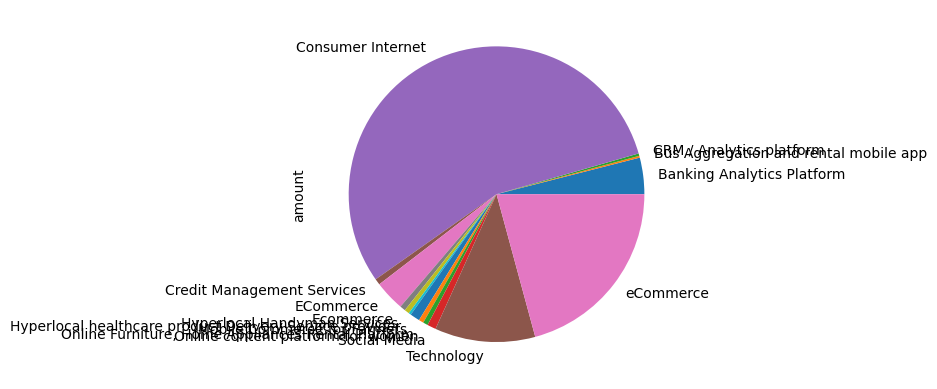

In [35]:
df[df['investors'].str.contains('IDG Ventures')].groupby('vertical')['amount'].sum().plot(kind='pie')

<Axes: ylabel='amount'>

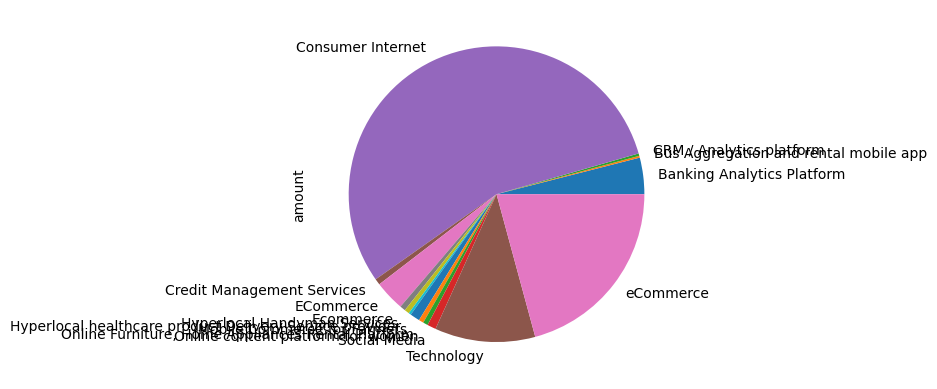

In [36]:
df[df['investors'].str.contains('IDG Ventures')].groupby('vertical')['amount'].sum().plot(kind='pie')

<Axes: ylabel='amount'>

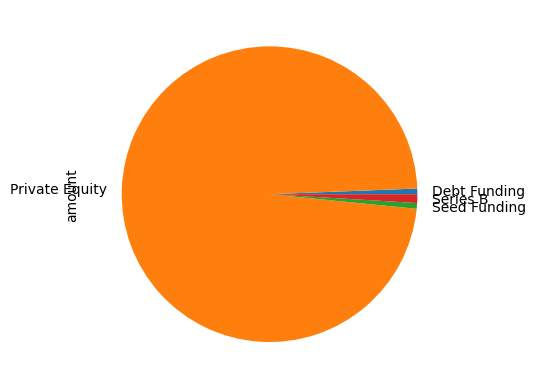

In [37]:
df[df['investors'].str.contains('IDG Ventures')].groupby('round')['amount'].sum().plot(kind='pie')

<Axes: ylabel='amount'>

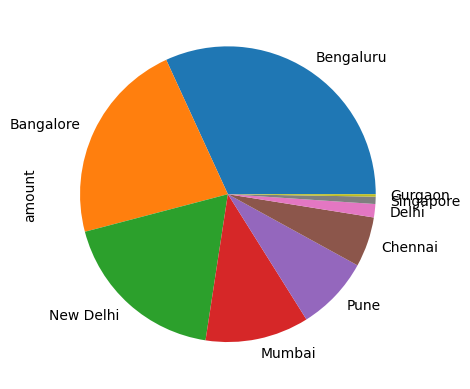

In [38]:
df[df['investors'].str.contains('IDG Ventures')].groupby('city')['amount'].sum().sort_values(ascending=False).plot(kind='pie')

In [39]:
df['date']=pd.to_datetime(df['date'])

In [40]:
df.info(
    
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2822 entries, 0 to 2821
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         2822 non-null   datetime64[ns]
 1   startup      2822 non-null   object        
 2   vertical     2822 non-null   object        
 3   subvertical  2078 non-null   object        
 4   city         2822 non-null   object        
 5   investors    2822 non-null   object        
 6   round        2822 non-null   object        
 7   amount       2822 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 176.5+ KB


In [41]:
df['year']=df['date'].dt.year

In [42]:
df.head()

,date,startup,vertical,subvertical,city,investors,round,amount,year
0,2020-09-01,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1650.000000,2020
1,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,66.399250,2020
2,2020-09-01,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,151.460595,2020
3,2020-02-01,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,24.750000,2020
4,2020-02-01,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,14.850000,2020


<Axes: xlabel='year'>

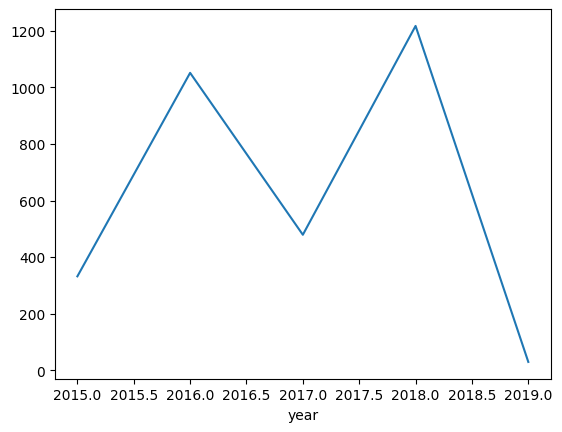

In [43]:
df[df['investors'].str.contains('IDG Ventures')].groupby('year')['amount'].sum().plot()

In [44]:
round(df['amount'].sum())

296492

In [45]:
max_amount = int(
    df.groupby('startup')['amount']
      .max()
      .sort_values(ascending=False)
      .iloc[0]
)

In [46]:
max_amount

32175

In [47]:
funded_startup=df['startup'].nunique()

In [48]:
df['month']=df['date'].dt.month

In [49]:
df.head()

,date,startup,vertical,subvertical,city,investors,round,amount,year,month
0,2020-09-01,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1650.000000,2020,9
1,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,66.399250,2020,1
2,2020-09-01,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,151.460595,2020,9
3,2020-02-01,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,24.750000,2020,2
4,2020-02-01,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,14.850000,2020,2


In [50]:
tem_df=df.groupby(['year','month'])['startup'].count().reset_index() # total number of startup funded 

In [57]:
x_axis=tem_df['year'].astype(str)+'-'+tem_df['month'].astype(str)

In [52]:
tem_df['x_axis']=x_axis

In [54]:
month_vise_funded_startup=tem_df[['x_axis','startup']]

In [55]:
month_vise_funded_startup

,x_axis,startup
0,2015-1,35
1,2015-2,14
2,2015-3,36
3,2015-4,65
4,2015-5,53
...,...,...
58,2019-12,10
59,2020-1,2
60,2020-2,2
61,2020-9,2
